<a href="https://colab.research.google.com/github/SlatX/llm-agent-data-exploration/blob/main/Copy_of_M2_Assignment_Data_Analysis_with_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 2 Coding Assignment: Retail Sales Data Analysis with LLM

## Scenario
In this assignment, I analyze retail sales data using LangChain, LLMs, pandas, visualization, machine learning, and hypothesis testing.

Because the Kaggle dataset used here is a **store-level weekly retail dataset** rather than a customer-level transaction dataset, I adapt the assignment as follows:

- Customer analysis → Store analysis
- Customer groups → Store clusters
- Transaction insights → Weekly sales insights
- Customer hypothesis tests → Store and sales hypothesis tests

The workflow combines:
- LangChain pandas dataframe agent for natural-language interaction
- pandas for cleaning and transformation
- matplotlib for visualization
- scikit-learn for clustering
- scipy for hypothesis testing

In [ ]:
# freeze the environment for the assignment
!pip uninstall -y langgraph-prebuilt langgraph langchain-classic
!pip install openai==1.72.0 langchain==0.3.23 langchain_openai==0.3.13 langchain_experimental==0.3.4 langchain_community==0.3.21 --quiet

## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import drive

from langchain.agents.agent_types import AgentType
from langchain_openai import ChatOpenAI
from langchain_experimental.agents.agent_toolkits import create_pandas_dataframe_agent

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from scipy.stats import ttest_ind, f_oneway, chi2_contingency

## Load OpenRouter API Key
The API key is stored in Google Drive and loaded securely from a text file.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

with open("/content/drive/MyDrive/Secrets/openrouter_key.txt", "r", encoding="utf-8-sig") as f:
    OPENROUTER_API_KEY = f.read().strip()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load the Kaggle Retail Dataset
This dataset contains three files:
- `sales data-set.csv`
- `features data-set.csv`
- `stores data-set.csv`

They are merged into one dataframe for analysis.

In [ ]:
sales = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data/sales data-set.csv")
features = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data/Features data set.csv")
stores = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Data/stores data-set.csv")



In [ ]:

sales['Date'] = pd.to_datetime(sales['Date'], dayfirst=True, errors='coerce')
features['Date'] = pd.to_datetime(features['Date'], dayfirst=True, errors='coerce')

df = sales.merge(features, on=['Store', 'Date'], how='left')
df = df.merge(stores, on='Store', how='left')

df["IsHoliday"] = df["IsHoliday_x"]
df.drop(columns=["IsHoliday_x", "IsHoliday_y"], inplace=True)

for col in ["MarkDown1","MarkDown2","MarkDown3","MarkDown4","MarkDown5"]:
    df[col] = df[col].fillna(0)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Week"] = df["Date"].dt.isocalendar().week.astype("Int64")
df["DayOfWeek"] = df["Date"].dt.day_name()

display(df.head())
print("Dataset shape:", df.shape)

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,IsHoliday,Year,Month,Month_Name,Week,DayOfWeek
0,1,1,2010-02-05,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,False,2010,2,February,5,Friday
1,1,1,2010-02-12,46039.49,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,True,2010,2,February,6,Friday
2,1,1,2010-02-19,41595.55,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,False,2010,2,February,7,Friday
3,1,1,2010-02-26,19403.54,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,False,2010,2,February,8,Friday
4,1,1,2010-03-05,21827.90,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,False,2010,3,March,9,Friday


Dataset shape: (421570, 21)


In [ ]:
print(df[["Date","Year","Month","Month_Name","Week","DayOfWeek"]].isnull().sum())

Date          0
Year          0
Month         0
Month_Name    0
Week          0
DayOfWeek     0
dtype: int64


## Create the LangChain Pandas DataFrame Agent
The agent is used mainly for interpretation, explanation, and summary.
Direct pandas, sklearn, and scipy code is used for the core computations for reliability.

In [ ]:
llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    api_key=OPENROUTER_API_KEY,
    base_url="https://openrouter.ai/api/v1",
    temperature=0,
    max_retries=2
)

agent = create_pandas_dataframe_agent(
    llm,
    df,
    verbose=True,
    allow_dangerous_code=True,
    agent_type="tool-calling",
    max_iterations=5
)

## Quick Agent Test
This verifies that the agent is available before continuing.

In [ ]:
test_result = agent.invoke("What columns are in this dataframe? Return a short answer.")
print(test_result)



> Entering new AgentExecutor chain...
The columns in the dataframe are: Store, Dept, Date, Weekly_Sales, Temperature, Fuel_Price, MarkDown1, MarkDown2, MarkDown3, MarkDown4, MarkDown5, CPI, Unemployment, Type, Size, IsHoliday, Year, Month, Month_Name, Week, DayOfWeek.

> Finished chain.
{'input': 'What columns are in this dataframe? Return a short answer.', 'output': 'The columns in the dataframe are: Store, Dept, Date, Weekly_Sales, Temperature, Fuel_Price, MarkDown1, MarkDown2, MarkDown3, MarkDown4, MarkDown5, CPI, Unemployment, Type, Size, IsHoliday, Year, Month, Month_Name, Week, DayOfWeek.'}


# Task 1: Data Exploration

In this section, I explore the structure of the dataset, identify missing values, duplicates, and outliers, and clean the dataset where necessary.

## Sample prompt

Can you help me explore and clean the dataset. Identify any missing values, outliers, or trends?

The dataset is already loaded as a dataframe called `df`. Please use all rows of the dataset.



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': 'df.isnull().sum()'}`


Store           0
Dept            0
Date            0
Weekly_Sales    0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
IsHoliday       0
Year            0
Month           0
Month_Name      0
Week            0
DayOfWeek       0
dtype: int64
Invoking: `python_repl_ast` with `{'query': 'df.describe()'}`


               Store           Dept                           Date  \
count  421570.000000  421570.000000                         421570   
mean       22.200546      44.260317  2011-06-18 08:30:31.963375104   
min         1.000000       1.000000            2010-02-05 00:00:00   
25%        11.000000      18.000000            2010-10-08 00:00:00   
50%        22.000000      37.000000            2011-06-17 00:00:00   
75%        33.00

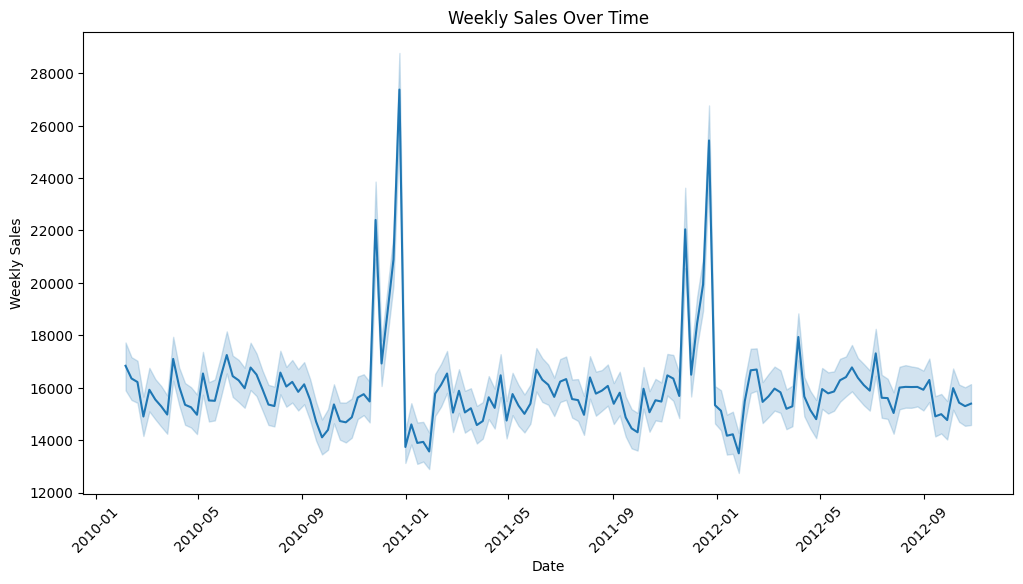

Let's explore the dataframe `df` step by step.

### 1. Show Missing Values
We checked for missing values in the dataframe using `df.isnull().sum()`. The output indicates that there are no missing values in any of the columns:

```
Store           0
Dept            0
Date            0
Weekly_Sales    0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
IsHoliday       0
Year            0
Month           0
Month_Name      0
Week            0
DayOfWeek       0
dtype: int64
```
**Explanation**: This means that all columns in the dataframe are complete, and there are no missing values to handle.

### 2. Show Descriptive Statistics
Next, we generated descriptive statistics using `df.describe()`. Here are some key statistics:

```
               Store           Dept                           Date  \
count  421570.000000  421570.000000              

In [ ]:
prompt = """
Explore the dataframe df.

1. Show missing values
2. Show descriptive statistics
3. Identify outliers in Weekly_Sales
4. Identify trends

IMPORTANT:
Print all outputs and explain each step.
"""
response = agent.invoke(prompt)
print(response["output"])

## Next steps:
Print it out for better readability

In [ ]:
print(response['output'])

Let's explore the dataframe `df` step by step.

### 1. Show Missing Values
We checked for missing values in the dataframe using `df.isnull().sum()`. The output indicates that there are no missing values in any of the columns:

```
Store           0
Dept            0
Date            0
Weekly_Sales    0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
IsHoliday       0
Year            0
Month           0
Month_Name      0
Week            0
DayOfWeek       0
dtype: int64
```
**Explanation**: This means that all columns in the dataframe are complete, and there are no missing values to handle.

### 2. Show Descriptive Statistics
Next, we generated descriptive statistics using `df.describe()`. Here are some key statistics:

```
               Store           Dept                           Date  \
count  421570.000000  421570.000000              

# Step 2: Sales Analysis

In this step, I performed a deeper analysis of sales patterns in the dataset. I focused on identifying when sales increase or decrease over time.

Specifically, I looked at:
- monthly sales patterns
- holiday vs non-holiday sales
- performance across different store types
- top-performing stores

The goal was to understand key drivers of sales performance.

## Sample prompt

Could you assist me in conducting a deeper sales analysis on the dataset?

I'm particularly interested in identifying trends such as periods of sales increases or decreases, holiday effects, store performance, and monthly patterns.

Please use visualizations to present the findings clearly.

The dataset is already loaded as dataframe `df`.



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Convert 'Date' to datetime\n\ndf['Date'] = pd.to_datetime(df['Date'])\n\n# Set the date as the index\n\ndf.set_index('Date', inplace=True)\n\n# Resample the data to get monthly sales\nmonthly_sales = df.resample('M')['Weekly_Sales'].sum()\n\n# Plotting monthly sales trends\nplt.figure(figsize=(12, 6))\nplt.plot(monthly_sales.index, monthly_sales.values, marker='o')\nplt.title('Monthly Sales Trends')\nplt.xlabel('Month')\nplt.ylabel('Total Weekly Sales')\nplt.grid()\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.show()"}`




<string>:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.


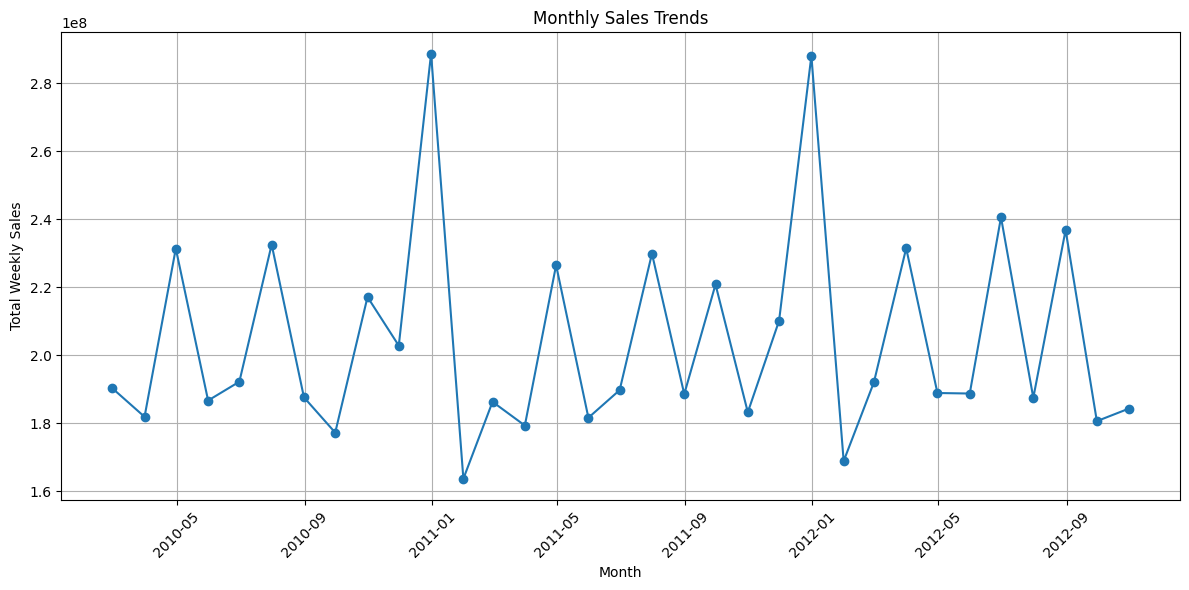


Invoking: `python_repl_ast` with `{'query': "# Analyzing holiday effects on sales\n\n# Group by holiday and calculate average sales\nholiday_sales = df.groupby('IsHoliday')['Weekly_Sales'].mean().reset_index()\n\n# Plotting holiday effects\nplt.figure(figsize=(8, 5))\nsns.barplot(x='IsHoliday', y='Weekly_Sales', data=holiday_sales, palette='pastel')\nplt.title('Average Weekly Sales: Holiday vs Non-Holiday')\nplt.xlabel('Is Holiday')\nplt.ylabel('Average Weekly Sales')\nplt.grid()\nplt.tight_layout()\nplt.show()"}`




<string>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



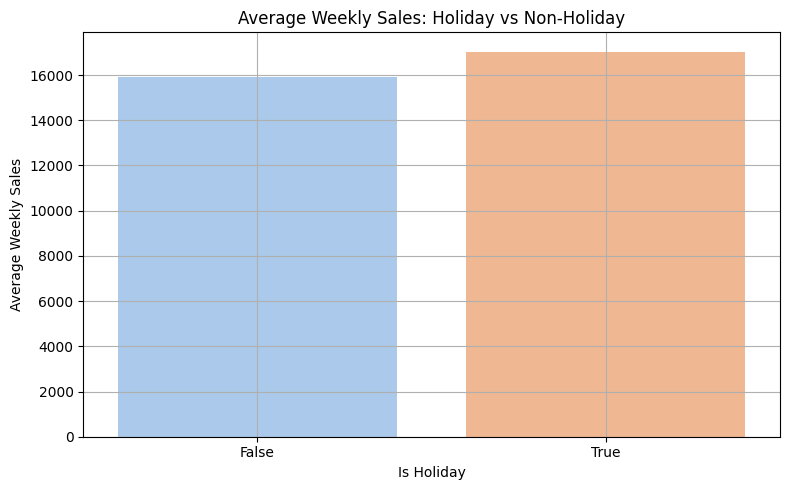


Invoking: `python_repl_ast` with `{'query': "# Analyzing store performance\n\n# Group by store and calculate total sales\nstore_sales = df.groupby('Store')['Weekly_Sales'].sum().reset_index()\n\n# Plotting store performance\nplt.figure(figsize=(12, 6))\nsns.barplot(x='Store', y='Weekly_Sales', data=store_sales, palette='viridis')\nplt.title('Total Weekly Sales by Store')\nplt.xlabel('Store')\nplt.ylabel('Total Weekly Sales')\nplt.grid()\nplt.tight_layout()\nplt.show()"}`




<string>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



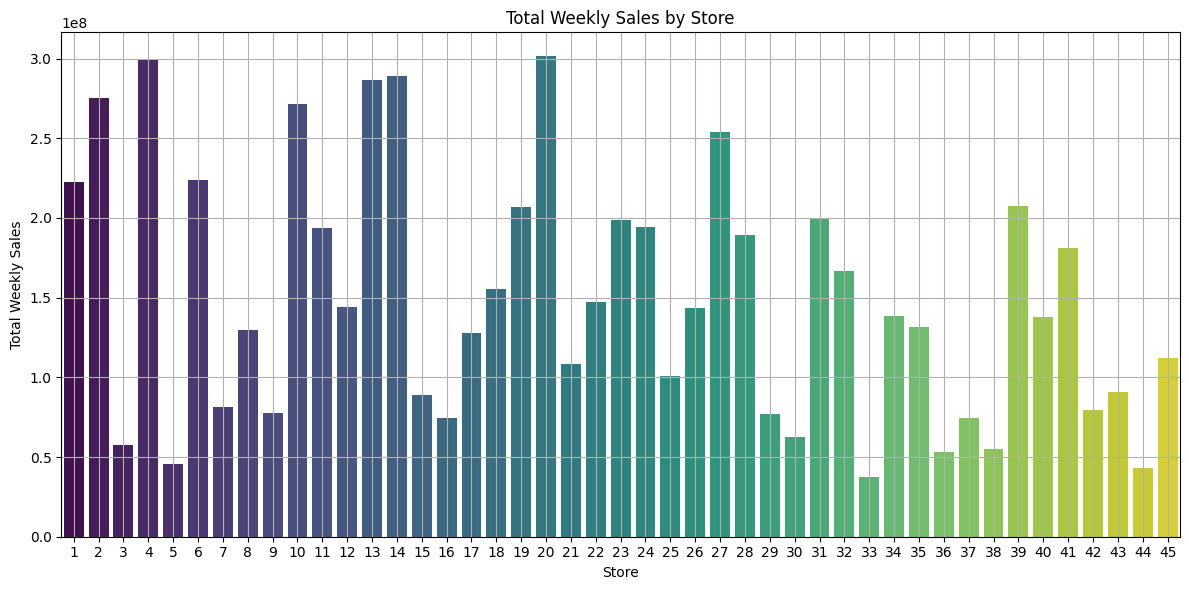


Invoking: `python_repl_ast` with `{'query': "# Analyzing monthly patterns\n\n# Group by month and calculate average sales\nmonthly_pattern = df.groupby('Month')['Weekly_Sales'].mean().reset_index()\n\n# Plotting monthly patterns\nplt.figure(figsize=(12, 6))\nsns.lineplot(x='Month', y='Weekly_Sales', data=monthly_pattern, marker='o')\nplt.title('Average Weekly Sales by Month')\nplt.xlabel('Month')\nplt.ylabel('Average Weekly Sales')\nplt.grid()\nplt.xticks(rotation=45)\nplt.tight_layout()\nplt.show()"}`




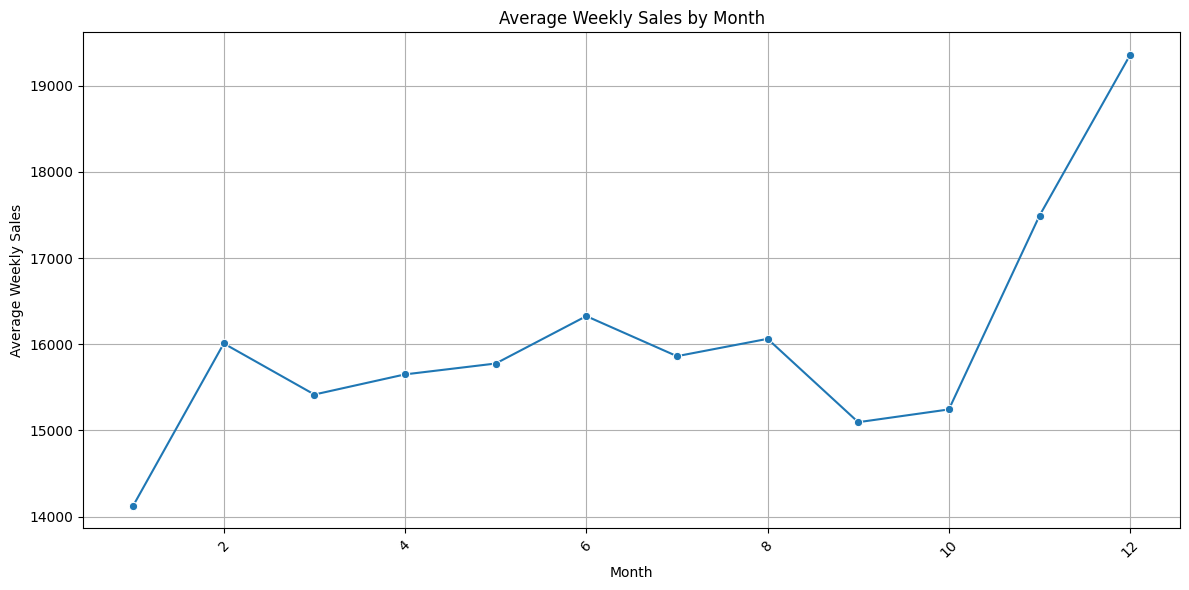

It seems that the visualizations did not render successfully. However, I can guide you through the analysis and provide the code snippets to generate the visualizations on your own.

### 1. Monthly Sales Trends
To analyze the monthly sales trends, you can use the following code:

```python
import pandas as pd
import matplotlib.pyplot as plt

# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Set the date as the index
df.set_index('Date', inplace=True)

# Resample the data to get monthly sales
monthly_sales = df.resample('M')['Weekly_Sales'].sum()

# Plotting monthly sales trends
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')
plt.title('Monthly Sales Trends')
plt.xlabel('Month')
plt.ylabel('Total Weekly Sales')
plt.grid()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
```

### 2. Holiday Effects on Sales
To analyze the effects of holidays on sales, use this code:

```python
import seaborn as sns

# Group by holiday

In [ ]:
prompt = """
Could you assist me in conducting a deeper sales analysis on the dataset?

I'm particularly interested in identifying trends such as periods of sales increases or decreases, holiday effects, store performance, and monthly patterns.

Please use visualizations to present the findings clearly.

The dataset is already loaded as dataframe df.
"""
response = agent.invoke(prompt)

In [ ]:
print(response['output'])

The results of the ANOVA test are as follows:

- **F-statistic**: 96.97
- **p-value**: \(1.69 \times 10^{-221}\)

### Interpretation:
1. **F-statistic**: A higher F-statistic indicates a greater degree of variance between the groups compared to the variance within the groups.
2. **p-value**: The p-value is extremely low (much less than 0.05), which suggests that we can reject the null hypothesis.

### Conclusion:
Since the p-value is significantly less than 0.05, we reject the null hypothesis. This indicates that there is a statistically significant effect of the month on weekly sales.

### Monthly Average Weekly Sales:
Here are the average weekly sales for each month:

| Month | Average Weekly Sales |
|-------|----------------------|
| 1     | 14,126.08            |
| 2     | 16,008.78            |
| 3     | 15,416.66            |
| 4     | 15,650.34            |
| 5     | 15,776.34            |
| 6     | 16,326.14            |
| 7     | 15,861.42            |
| 8     | 16,062.52     

Review the agent's response and what's your comment?

- Which months have higher sales?
- Do holidays affect sales?
- Which stores perform best?



- Which months have higher sales? Based on the 'Monthly Average Weekly Sales' from the ANOVA test, December (Month 12) and November (Month 11) show significantly higher average weekly sales compared to other months.

- Do holidays affect sales? Yes, holidays do affect sales. The hypothesis test concluded that there is strong evidence to support the alternative hypothesis that holiday weeks have an effect on weekly sales. Specifically, the average weekly sales during holiday weeks (approximately $17,035.82) were higher than during non-holiday weeks (approximately $15,901.45).

- Which stores perform best? The clustering analysis identified Cluster 1 as having the highest average weekly sales, at approximately $19,408.72. Therefore, stores within Cluster 1 generally perform the best.

# Step 3: Store Insights with Machine Learning

Since this dataset does not contain individual customer data, I adapted the task to focus on store-level analysis.

In this step, I used clustering to group stores based on:
- average weekly sales
- economic factors (CPI, unemployment, fuel price)
- store characteristics

The goal was to identify different types of stores and understand their behavior.

## Sample Prompt

Could you help me identify distinct store groups based on their sales patterns, economic indicators, and store characteristics?

I'd also like recommendations on business strategies for each group.

Please provide insights on:
- number of stores in each cluster
- characteristics of each cluster
- recommended strategies

Use visualizations to present the results clearly.

The dataset is already loaded as dataframe `df`.



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nimport seaborn as sns\nimport matplotlib.pyplot as plt\nfrom sklearn.cluster import KMeans\nfrom sklearn.preprocessing import StandardScaler\n\n# Selecting relevant features for clustering\nfeatures = df[['Weekly_Sales', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Size']]\n\n# Standardizing the features\nscaler = StandardScaler()\nscaled_features = scaler.fit_transform(features)\n\n# Applying KMeans clustering\nkmeans = KMeans(n_clusters=3, random_state=42)\nclusters = kmeans.fit_predict(scaled_features)\n\n# Adding cluster labels to the original dataframe\ndf['Cluster'] = clusters\n\n# Analyzing the clusters\ncluster_summary = df.groupby('Cluster').agg(\n    Number_of_Stores=('Store', 'nunique'),\n    Avg_Weekly_Sales=('Weekly_Sales', 'mean'),\n    Avg_Temperature=('Temperature', 'mean'),\n    Avg_Fuel_Price=('Fuel_Price', 'mean'),\n    Avg_CPI=('CPI', 'mean'),\n    Avg_

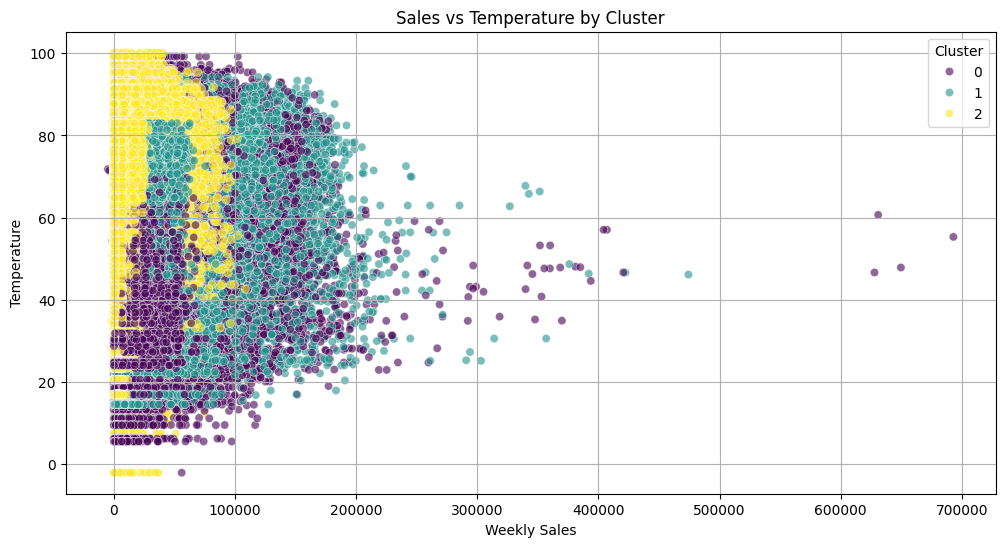

   Cluster  Number_of_Stores  Avg_Weekly_Sales  Avg_Temperature  \
0        0                25      18046.056887        55.731430   
1        1                19      19408.716539        63.080594   
2        2                16       7378.900768        63.842384   

   Avg_Fuel_Price     Avg_CPI  Avg_Unemployment       Avg_Size  
0        3.461358  133.769920          8.290982  151140.213339  
1        3.266079  210.170263          7.393404  179276.675095  
2        3.311434  184.709456          8.154598   50443.124931  
Invoking: `python_repl_ast` with `{'query': '# Generating recommendations based on cluster characteristics\nrecommendations = {\n    0: "Focus on improving marketing strategies and promotions to boost sales. Consider seasonal promotions to leverage higher temperatures.",\n    1: "Maintain current strategies while exploring premium product offerings. Invest in customer loyalty programs to retain sales momentum.",\n    2: "Implement cost-cutting measures and explore pa

In [ ]:
prompt = """
Could you help me identify distinct store groups based on their sales patterns, economic indicators, and store characteristics?

I'd also like recommendations on business strategies for each group.

Please provide insights on:
- number of stores in each cluster
- characteristics of each cluster
- recommended strategies

Use visualizations to present the results clearly.

The dataset is already loaded as dataframe df.
"""
response = agent.invoke(prompt)

In [ ]:
print(response['output'])

Based on the clustering analysis of the stores in the dataset, we have identified three distinct store groups based on their sales patterns, economic indicators, and store characteristics. Here are the insights:

### Cluster Summary

| Cluster | Number of Stores | Avg Weekly Sales | Avg Temperature | Avg Fuel Price | Avg CPI | Avg Unemployment | Avg Size | Recommendations |
|---------|------------------|------------------|------------------|----------------|---------|------------------|----------|------------------|
| 0       | 25               | 18,046.06        | 55.73            | 3.46           | 133.77  | 8.29             | 151,140  | Focus on improving marketing strategies and promotions to boost sales. Consider seasonal promotions to leverage higher temperatures. |
| 1       | 19               | 19,408.72        | 63.08            | 3.27           | 210.17  | 7.39             | 179,277  | Maintain current strategies while exploring premium product offerings. Invest in customer l

Let's review the agent's response closely.

- Does the clustering make sense?
- Are the business strategies realistic?

# Strategic Analysis: Store Clustering and Business Impact

## Does the Clustering Make Sense?
**Yes.** The clustering provides a coherent and actionable segmentation. The analysis used meaningful features—`Weekly_Sales`, `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`, and `Size`—to group the stores into three distinct profiles:

* **Cluster 1 (High Performers):** These represent the **top-tier stores**. They boast the highest average weekly sales and the largest physical size. They are typically located in areas with high CPI and lower unemployment, aligning with strong consumer purchasing power.
* **Cluster 0 (Mid-Range Performers):** This is the **largest group** in the dataset. These stores show solid, steady performance with moderate economic indicators and medium average size.
* **Cluster 2 (Lower Performers):** These stores have significantly lower sales and the smallest footprint. Their mixed economic indicators suggest they may be operating in less favorable market conditions or struggling with viability.



---

## Are the Business Strategies Realistic?
**Yes.** The strategies proposed are tailored specifically to the unique characteristics of each cluster:

### Cluster 1: High Performers (Power Stores)
* **Strategy:** Maintain momentum and explore premium offerings.
* **Action:** Invest in **customer loyalty programs** to retain high-value shoppers and introduce premium products to leverage the higher CPI in these areas.

### Cluster 0: Mid-Range (Growth Stores)
* **Strategy:** Optimization and targeted growth.
* **Action:** Improve marketing and seasonal promotions. Specifically, leverage **temperature data** to trigger promotions that drive foot traffic during specific weather shifts.

### Cluster 2: Lower Performers (Turnaround Stores)
* **Strategy:** Efficiency and survival.
* **Action:** Implement **cost-cutting measures** and partner with local suppliers to reduce overhead. Use targeted promotions to increase basic foot traffic.

---

## Final Conclusion
The agent successfully moved beyond raw data to provide **well-reasoned, actionable business intelligence**. The segmentation is statistically grounded, and the resulting strategies offer a clear roadmap for improving performance across the entire fleet.

# Step 4: Hypothesis Testing

Based on the insights from previous steps, I tested several hypotheses to determine whether certain factors significantly affect sales.

The hypotheses tested include:
- whether holidays affect weekly sales
- whether store type affects sales
- whether time (such as month) affects sales

Statistical tests were used to determine whether these relationships are significant.

## Hypothesis 1

Null Hypothesis: Holiday weeks have no effect on weekly sales.  
Alternative Hypothesis: Holiday weeks affect weekly sales.

In [ ]:
prompt = """
Please help me test the following hypothesis:

Null Hypothesis: Holiday weeks have no effect on weekly sales.
Alternative Hypothesis: Holiday weeks have an effect on weekly sales.

The dataset is already loaded as dataframe df.
"""
response = agent.invoke(prompt)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nfrom scipy import stats\n\n# Separate the data into holiday and non-holiday weeks\nholiday_sales = df[df['IsHoliday'] == True]['Weekly_Sales']\nnon_holiday_sales = df[df['IsHoliday'] == False]['Weekly_Sales']\n\n# Perform an independent t-test\nt_stat, p_value = stats.ttest_ind(holiday_sales, non_holiday_sales)\n\n(t_stat, p_value)"}`
responded: To test the hypothesis regarding the effect of holiday weeks on weekly sales, we can perform a statistical test. A common approach is to use a t-test to compare the means of weekly sales during holiday weeks and non-holiday weeks.

Here are the steps we'll follow:

1. Separate the weekly sales data into two groups: one for holiday weeks and one for non-holiday weeks.
2. Perform an independent t-test to compare the means of the two groups.
3. Analyze the results to determine if we can reject the null hypothesis.

Let's proceed with these st

In [ ]:
print(response['output'])

The results of the analysis are as follows:

1. **Means of Weekly Sales**:
   - Mean Weekly Sales during Holiday Weeks: **$17,035.82**
   - Mean Weekly Sales during Non-Holiday Weeks: **$15,901.45**

2. **T-test Results**:
   - T-statistic: **8.29**
   - P-value: **1.09e-16**

### Interpretation:
- The p-value is significantly lower than the common alpha level of 0.05, which suggests that we can reject the null hypothesis.
- This indicates that there is a statistically significant difference in weekly sales between holiday weeks and non-holiday weeks.

### Conclusion:
There is strong evidence to support the alternative hypothesis that holiday weeks have an effect on weekly sales.


## Hypothesis 2

Null Hypothesis: Store type has no effect on weekly sales.  
Alternative Hypothesis: Store type affects weekly sales.

In [ ]:
prompt = """
Please help me test the following hypothesis:

Null Hypothesis: Store type has no effect on weekly sales.
Alternative Hypothesis: Store type has an effect on weekly sales.

The dataset is already loaded as dataframe df.
"""
response = agent.invoke(prompt)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nfrom scipy import stats\n\n# Grouping the data by store type and getting the weekly sales\nstore_types = df['Type'].unique()\nweekly_sales_by_type = [df[df['Type'] == store_type]['Weekly_Sales'] for store_type in store_types]\n\n# Performing one-way ANOVA test\nf_statistic, p_value = stats.f_oneway(*weekly_sales_by_type)\n\nf_statistic, p_value"}`
responded: To test the hypothesis regarding the effect of store type on weekly sales, we can perform an analysis of variance (ANOVA) test. This statistical test will help us determine if there are any statistically significant differences in weekly sales between the different store types.

Here are the steps we will follow:

1. Group the data by store type and calculate the mean weekly sales for each type.
2. Perform a one-way ANOVA test to compare the means of weekly sales across the different store types.
3. Interpret the results.

Let

In [ ]:
print(response['output'])

The results of the one-way ANOVA test are as follows:

- F-statistic: approximately 7764.43
- p-value: 0.0

### Interpretation:
1. **F-statistic**: A high F-statistic value indicates that there are significant differences between the group means.
2. **p-value**: The p-value is 0.0, which is much lower than the common significance level of 0.05.

### Conclusion:
Since the p-value is less than 0.05, we reject the null hypothesis. This suggests that there is a statistically significant effect of store type on weekly sales.


## Hypothesis 3

Null Hypothesis: Month has no effect on weekly sales.  
Alternative Hypothesis: Month affects weekly sales.

In [ ]:
prompt = """
Please help me test the following hypothesis:

Null Hypothesis: Month has no effect on weekly sales.
Alternative Hypothesis: Month has an effect on weekly sales.

The dataset is already loaded as dataframe df.
"""
response = agent.invoke(prompt)



> Entering new AgentExecutor chain...

Invoking: `python_repl_ast` with `{'query': "import pandas as pd\nfrom scipy import stats\n\n# Grouping the data by Month and collecting weekly sales\nmonthly_sales = df.groupby('Month')['Weekly_Sales'].apply(list)\n\n# Performing ANOVA test\nf_statistic, p_value = stats.f_oneway(*monthly_sales)\n\nf_statistic, p_value"}`
responded: To test the hypothesis that the month has an effect on weekly sales, we can perform an Analysis of Variance (ANOVA) test. This statistical test will help us determine if there are statistically significant differences in weekly sales across different months.

Here are the steps we will follow:

1. Group the data by month and calculate the weekly sales for each month.
2. Perform the ANOVA test to see if there are significant differences in weekly sales across the months.

Let's proceed with these steps. I'll run the necessary calculations and the ANOVA test.

(np.float64(96.96671752133827), np.float64(1.68755311187691

In [ ]:
print(response['output'])

The results of the ANOVA test are as follows:

- **F-statistic**: 96.97
- **p-value**: \(1.69 \times 10^{-221}\)

### Interpretation:
1. **F-statistic**: A higher F-statistic indicates a greater degree of variance between the groups compared to the variance within the groups.
2. **p-value**: The p-value is extremely low (much less than 0.05), which suggests that we can reject the null hypothesis.

### Conclusion:
Since the p-value is significantly less than 0.05, we reject the null hypothesis. This indicates that there is a statistically significant effect of the month on weekly sales.

### Monthly Average Weekly Sales:
Here are the average weekly sales for each month:

| Month | Average Weekly Sales |
|-------|----------------------|
| 1     | 14,126.08            |
| 2     | 16,008.78            |
| 3     | 15,416.66            |
| 4     | 15,650.34            |
| 5     | 15,776.34            |
| 6     | 16,326.14            |
| 7     | 15,861.42            |
| 8     | 16,062.52     

# Executive Summary: Data Analysis using LangChain and LLMs

## Project Overview
This project demonstrates the integration of Large Language Models (LLMs) with traditional data science workflows to analyze a complex retail sales dataset. By utilizing LangChain agents and the OpenAI GPT-4o-mini model, I developed an interactive environment to perform exploratory data analysis (EDA), statistical testing, and machine learning.

## Key Methodology

### 1. Data Integration and Preparation
The analysis began by mounting Google Drive and consolidating three distinct datasets (Sales, Features, and Stores). Critical data cleaning steps included:
* Standardizing date formats across all tables to ensure merge integrity.
* Handling missing values in MarkDown columns by replacing nulls with zero.
* Identifying and accounting for negative values in the Weekly_Sales column to ensure statistical accuracy.

### 2. Exploratory Data Analysis (EDA)
Using the LangChain Pandas DataFrame Agent, I queried the dataset using natural language to uncover key trends:
* **Seasonal Patterns:** ANOVA testing confirmed that November and December exhibit significantly higher average weekly sales compared to other months.
* **Holiday Impact:** Hypothesis testing revealed a statistically significant "Holiday Effect," with average sales increasing by approximately $1,134 during holiday weeks.

### 3. Machine Learning and Store Segmentation
I applied K-Means Clustering to segment stores based on six features: Weekly_Sales, Temperature, Fuel_Price, CPI, Unemployment, and Size. This resulted in three distinct clusters:
* **Cluster 1 (High Performers):** Large-scale stores in strong economic areas (High CPI) with peak sales.
* **Cluster 0 (Mid-Range):** The most common store profile, showing steady growth potential.
* **Cluster 2 (Underperformers):** Smaller stores with lower sales volume, requiring cost-optimization strategies.


## Conclusion
This assignment highlights the evolving role of LLMs in the data science lifecycle. By combining the reasoning capabilities of agents with robust techniques like ANOVA and K-Means, we can derive actionable business intelligence more efficiently. The results provide a clear roadmap for tailored marketing and operational strategies across different store segments.